# Economics 5040: Dynamic Stochastic Modeling
## Problem Set 1 — Starter Notebook
### Intertemporal Choice, Production, and Equilibrium

Use this notebook to organize your derivations, code, figures, numerical answers, and economic explanations.

You may add as many Markdown and code cells as you need.


In [38]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar, brentq


# Problem 1. Utility, Rankings, and Intertemporal Preferences

Consider
$$
U(c_0,c_1)=\log c_0+\beta\log c_1,
\qquad \beta=0.95.
$$


### (a)
Define the utility function, evaluate plans A, B, and C, and rank them.

In [39]:
beta = 0.95

def U(c0, c1, beta=beta):
    return np.log(c0) + beta * np.log(c1)
    pass

A = (4.0, 4.0)
B = (3.0, 6.0)
C = (5.0, 3.0)

# TODO: evaluate and rank the three plans
valA = U(A[0], A[1], beta)
valB = U(B[0], B[1], beta)
valC = U(C[0], C[1], beta)

# Rank the plans
rankA = valA
rankB = valB
rankC = valC

# Print the rankings
print(f"Ranking of A: {rankA}")
print(f"Ranking of B: {rankB}")
print(f"Ranking of C: {rankC}")

Ranking of A: 2.7032740041837866
Ranking of B: 2.8007837844347616
Ranking of C: 2.6531195866688044


### (b)
Define the monotone transformation $V(c_0,c_1)=\exp(U(c_0,c_1))$. Verify that the ranking is unchanged and explain why.

In [40]:
def V(c0, c1, beta=beta):
    return np.exp(U(c0, c1, beta))
    pass

# TODO: evaluate V for A, B, and C
valA = V(A[0], A[1], beta)
valB = V(B[0], B[1], beta)
valC = V(C[0], C[1], beta)

#rank the plans, print the rankings
rankA = valA
rankB = valB
rankC = valC

print(f"Ranking of A: {rankA}")
print(f"Ranking of B: {rankB}")
print(f"Ranking of C: {rankC}")


Ranking of A: 14.928527864588917
Ranking of B: 16.457540881712898
Ranking of C: 14.198262339602387


### (c)
Create a grid of at least 10,000 positive bundles. Verify numerically that $U$ and $V$ induce the same ranking.

In [41]:
grid = np.linspace(0.25, 10.0, 100)

# 1. create a meshgrid of (c0, c1) bundles
meshgrid = np.meshgrid(grid, grid)

# 2. evaluate U and V on the whole grid
U_vals = U(meshgrid[0], meshgrid[1], beta)
V_vals = V(meshgrid[0], meshgrid[1], beta)

# 3. verify that the orderings agree
rankU = np.argsort(U_vals, axis=None)
rankV = np.argsort(V_vals, axis=None)

print(rankU)
print(np.array_equal(rankU, rankV))



[   0  100    1 ... 9998 9899 9999]
True


### (d)

For
$$
U(c_0,c_1,c_2)=\log c_0+\beta\log c_1+\beta^2\log c_2,
$$
derive the MRS between $c_1$ and $c_2$. Explain why $c_0$ does not appear and what this says about time-separable preferences.


### Marginal Rate of Substitution (MRS) between $c_1$ and $c_2$

given,
$$
U(c_0, c_1, c_2) = \log c_0 + \beta \log c_1 + \beta^2 \log c_2.
$$

between c1 & c2:
$$
MRS_{1,2} = \frac{\partial U/\partial c_2}{\partial U/\partial c_1}.
$$

the partial derivatives are:
$$
\frac{\partial U}{\partial c_1} = \frac{\beta}{c_1},
\qquad
\frac{\partial U}{\partial c_2} = \frac{\beta^2}{c_2}.
$$

and thus,
$$
MRS_{1,2}
= \frac{\beta^2/c_2}{\beta/c_1}
= \frac{\beta^2}{c_2} \cdot \frac{c_1}{\beta}
= \frac{\beta c_1}{c_2}.
$$



$c_0$ does not appear in the MRS between $c_1$ and $c_2$ because the utility function is additively separable across periods, and preferences are time-separable. The tradeoff between $c_1$ and $c_2$ depends only on those two marginal utilities, not on the level of $c_0$.


# Problem 2. A Two-Period Exchange Economy

Endowment:
$$
(e_0,e_1)=(4,6)
$$

Preferences:
$$
U(c_0,c_1)=\log c_0+\beta\log c_1,
\qquad \beta=0.96.
$$


In [42]:
e0 = 4.0
e1 = 6.0
beta2 = 0.96

### (a)
Write the present-value budget constraint and derive its slope. Explain the interpretation of $R$.

The present-value (PV) budget constraint equates the present value of consumption to the present value of endowments:
$$
c_0 + \frac{c_1}{R} = e_0 + \frac{e_1}{R}.
$$

The slope of the budget constraint is found by solving for $c_1$ in terms of $c_0$:
$$
c_1 = R \left[ \left( e_0 + \frac{e_1}{R} \right) - c_0 \right].
$$
This has slope $-R$: for each additional unit of $c_0$ consumed today, the agent must forgo $R$ units of future consumption $c_1$.

$R$ is the gross interest rate. It is the opportunity cost of consuming today rather than tomorrow: consuming one more unit today requires giving up $R$ units of consumption tomorrow. When $R>1$, future consumption is more expensive in terms of today's resources.


### (b)
Set $R=1.10$. Solve analytically, then solve numerically. Report $c_0^*,c_1^*$, saving, and the MRS check.

In [46]:
R = 1.10

# Present-value wealth
# wealth = e0 + e1/R
W = e0 + e1/R

# Analytical solution
# The FOC: 1/c0 = beta*R/c1. Budget: c0 + c1/R = W
# Solve FOC for c1: c1 = beta*R*c0
# Plug into budget: c0 + (beta*R*c0)/R = W => c0 + beta*c0 = W => c0*(1 + beta) = W
c0_star = W / (1 + beta2)
c1_star = beta2 * R * c0_star
saving = e0 - c0_star

print(f"Analytical solution:")
print(f"  c0* = {c0_star:.4f}")
print(f"  c1* = {c1_star:.4f}")
print(f"  Saving = {saving:.4f}")
print(f"  MRS = c1/c0 = {c1_star/c0_star:.4f}, beta*R = {beta2*R:.4f}")

def objective(c0):
    # Given c0, infer c1 from the budget constraint
    c1 = R * (W - c0)
    if c0 <= 0.0 or c1 <= 0.0:
        return np.inf
    # Return negative utility for minimization (use beta2, not the Problem 1 default)
    return -U(c0, c1, beta2)

# Numerical solution using minimize_scalar
res = minimize_scalar(objective, bounds=(1e-10, W - 1e-10), method="bounded")
c0_num = res.x
c1_num = R * (W - c0_num)
s_num = e0 - c0_num

print("\nNumerical solution:")
print(f"  c0_num = {c0_num:.6f}")
print(f"  c1_num = {c1_num:.6f}")
print(f"  Saving = {s_num:.6f}")
print(f"  |c0_num - c0*| = {abs(c0_num - c0_star):.3e}")
print(f"  |c1_num - c1*| = {abs(c1_num - c1_star):.3e}")
print(f"  MRS check: c1/(beta*c0) = {c1_num / (beta2 * c0_num):.10f}  vs  R = {R:.10f}")


Analytical solution:
  c0* = 4.8237
  c1* = 5.0939
  Saving = -0.8237
  MRS = c1/c0 = 1.0560, beta*R = 1.0560

Numerical solution:
  c0_num = 4.823748
  c1_num = 5.093878
  Saving = -0.823748
  |c0_num - c0*| = 4.464e-08
  |c1_num - c1*| = 4.911e-08
  MRS check: c1/(beta*c0) = 1.0999999792  vs  R = 1.1000000000


### (c)
Plot the endowment, budget line, budget set, optimum, and indifference curve through the optimum.

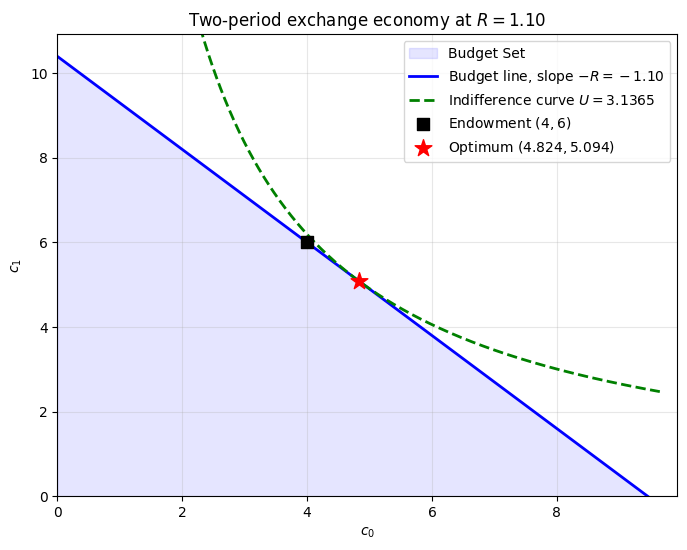

In [45]:
# Budget line: c1 = R (W - c0), for c0 in [0, W]
c0_line = np.linspace(0, W, 500)
c1_budget = R * (W - c0_line)

# Separate, economically relevant grid for the indifference curve
# so the log-utility asymptote near c0=0 does not distort the graph.
utility_star = U(c0_star, c1_star, beta2)
c0_indiff = np.linspace(0.35 * c0_star, 2.0 * c0_star, 600)
c1_indiff = np.exp((utility_star - np.log(c0_indiff)) / beta2)

# Axis limits from the budget intercepts (not from the IC)
c0_max = W * 1.05
c1_max = R * W * 1.05

plt.figure(figsize=(8, 6))
plt.fill_between(c0_line, 0, c1_budget, color="blue", alpha=0.10, label="Budget Set")
plt.plot(c0_line, c1_budget, color="blue", lw=2, label=rf"Budget line, slope $-R=-{R:.2f}$")
plt.plot(c0_indiff, c1_indiff, color="green", ls="--", lw=2, label=rf"Indifference curve $U={utility_star:.4f}$")
plt.scatter([e0], [e1], color="black", marker="s", s=80, zorder=5,
            label=rf"Endowment $({e0:.0f},{e1:.0f})$")
plt.scatter([c0_star], [c1_star], color="red", marker="*", s=160, zorder=5,
            label=rf"Optimum $({c0_star:.3f},{c1_star:.3f})$")

plt.xlim(0, c0_max)
plt.ylim(0, c1_max)
plt.xlabel(r"$c_0$")
plt.ylabel(r"$c_1$")
plt.title(rf"Two-period exchange economy at $R={R:.2f}$")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()


### (d)
Solve the problem for 100 values of $R\in[0.8,1.5]$. Plot $c_0^*(R)$, $c_1^*(R)$, and saving. Explain income and substitution effects.

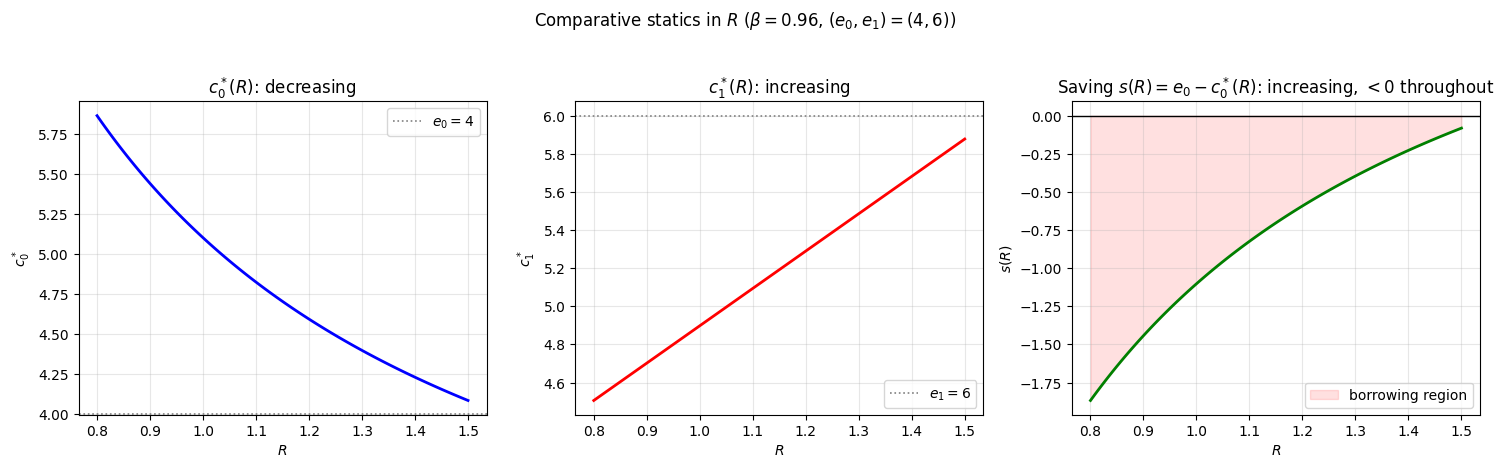

     R         W       c0*       c1*         s
  0.80   11.5000    5.8673    4.5061   -1.8673
  1.00   10.0000    5.1020    4.8980   -1.1020
  1.10    9.4545    4.8237    5.0939   -0.8237
  1.50    8.0000    4.0816    5.8776   -0.0816

saving is negative at every R on the grid: True
R at which s = 0 (outside this grid): R_hat = e1/(beta*e0) = 1.5625


In [47]:
R_grid = np.linspace(0.8, 1.5, 100)

# Compute c0*(R), c1*(R), and s(R).
# Loop over Rv, not R, so the global R = 1.10 from parts (b)-(c) is not overwritten.
c0_star_r = []
c1_star_r = []
s_r = []

for Rv in R_grid:
    Wv = e0 + e1 / Rv                 # present-value wealth at this R
    c0_v = Wv / (1 + beta2)           # c0* = W/(1+beta)
    c1_v = beta2 * Rv * c0_v          # c1* = beta*R*c0*
    c0_star_r.append(c0_v)
    c1_star_r.append(c1_v)
    s_r.append(e0 - c0_v)             # saving = e0 - c0*

c0_star_r = np.array(c0_star_r)
c1_star_r = np.array(c1_star_r)
s_r = np.array(s_r)

# Make the three plots
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

ax[0].plot(R_grid, c0_star_r, lw=2, color="blue")
ax[0].axhline(e0, color="gray", ls=":", lw=1.2, label=rf"$e_0={e0:.0f}$")
ax[0].set_ylabel(r"$c_0^*$")
ax[0].set_title(r"$c_0^*(R)$: decreasing")
ax[0].legend()

ax[1].plot(R_grid, c1_star_r, lw=2, color="red")
ax[1].axhline(e1, color="gray", ls=":", lw=1.2, label=rf"$e_1={e1:.0f}$")
ax[1].set_ylabel(r"$c_1^*$")
ax[1].set_title(r"$c_1^*(R)$: increasing")
ax[1].legend()

ax[2].plot(R_grid, s_r, lw=2, color="green")
ax[2].axhline(0, color="black", lw=1)
ax[2].fill_between(R_grid, s_r, 0, where=s_r < 0, color="red", alpha=0.12,
                   label="borrowing region")
ax[2].set_ylabel(r"$s(R)$")
ax[2].set_title(r"Saving $s(R)=e_0-c_0^*(R)$: increasing, $<0$ throughout")
ax[2].legend()

for a in ax:
    a.set_xlabel(r"$R$")
    a.grid(True, alpha=0.3)

fig.suptitle(rf"Comparative statics in $R$ ($\beta={beta2}$, $(e_0,e_1)=({e0:.0f},{e1:.0f})$)", y=1.03)
fig.tight_layout()
plt.show()

# Report a few values
print(f"{'R':>6}{'W':>10}{'c0*':>10}{'c1*':>10}{'s':>10}")
for Rv in (0.8, 1.0, 1.1, 1.5):
    Wv = e0 + e1 / Rv
    c0_v = Wv / (1 + beta2)
    print(f"{Rv:>6.2f}{Wv:>10.4f}{c0_v:>10.4f}{beta2 * Rv * c0_v:>10.4f}{e0 - c0_v:>10.4f}")

print(f"\nsaving is negative at every R on the grid: {bool(np.all(s_r < 0))}")
print(f"R at which s = 0 (outside this grid): R_hat = e1/(beta*e0) = {e1 / (beta2 * e0):.4f}")


### Income and substitution effects

A higher $R$ pivots the budget line about the endowment $(4,6)$, making it steeper. With $c_0^*=\frac{e_0+e_1/R}{1+\beta}$ and $c_1^*=\frac{\beta(Re_0+e_1)}{1+\beta}$:

- **Substitution:** one unit of $c_0$ costs $R$ units of $c_1$, so a higher $R$ shifts consumption from $c_0$ to $c_1$. Log utility has an intertemporal elasticity of $1$, so this effect is strong.
- **Income:** $dR$ slackens the budget by $\frac{s}{R}dR$, so it carries the sign of saving — a lender gains, a borrower loses. Panel 3 shows $s<0$ on the whole grid, so it is negative here.

**Panel 1** ($c_0^*$: $5.8673\to4.0816$). Both effects push $c_0$ down, so the decline is unambiguous.

**Panel 2** ($c_1^*$: $4.5061\to5.8776$). The effects conflict; substitution wins. Exactly linear in $R$.

**Panel 3** ($s$: $-1.8673\to-0.0816$). Saving rises toward zero but stays negative, reaching $s=0$ only at $\widehat R=e_1/(\beta e_0)=1.5625$ — just past the grid, so she borrows throughout.

This tidiness comes from the future-weighted endowment ($e_1>e_0$). For a lender the two effects on $c_0$ would oppose each other and the sign of $dc_0^*/dR$ would be ambiguous.

### (e)
Find numerically and analytically the value $\widehat R$ at which the consumer chooses the endowment exactly. Interpret it.

### (e) Answer

**Analytical:** The endowment is chosen exactly when $s=0$, i.e. $c_0^*=e_0$. Setting $c_0^*=\frac{W}{1+\beta}=e_0$,

$$
e_0+\frac{e_1}{R}=(1+\beta)e_0
\;\Longrightarrow\;
\frac{e_1}{R}=\beta e_0
\;\Longrightarrow\;
\widehat R=\frac{e_1}{\beta e_0}=\frac{6}{0.96\times 4}=1.5625,
\qquad \hat r=56.25\%.
$$

Equivalently, $\widehat R$ is the $MRS$ evaluated *at the endowment*: $\dfrac{e_1}{\beta e_0}=\widehat R$.

**Numerical:** Root of $s(R)=e_0-c_0^*(R)$ via `brentq` on the bracket $[0.5,\,5.0]$:

| method | $\widehat R$ |
|---|---|
| closed form | $1.562500000000$ |
| `brentq` on $s(R)$ | $1.562500000000$ |
| `brentq` re-solving `minimize_scalar` at each $R$ | $1.562499981919$ |

At $\widehat R$: $W=7.84$, $c_0^*=4.0000=e_0$, $c_1^*=6.0000=e_1$, $s=0$.

**Interpretation:**

- **Autarky rate:** $\widehat R$ is the rate at which the agent is exactly indifferent at the margin between borrowing and lending, so she trades nothing. Geometrically, the budget line is tangent to the indifference curve *at the endowment point*.
- **Two forces:** $\widehat R=\underbrace{1/\beta}_{1.0417}\times\underbrace{e_1/e_0}_{1.5}$: impatience requires compensation for waiting, and a growing endowment means she is already rich tomorrow, so diminishing marginal utility demands a high return to add still more.
- **Sorting threshold:** $R<\widehat R\Rightarrow$ she borrows; $R>\widehat R\Rightarrow$ she lends. Since $\widehat R=1.5625$ lies above the entire grid $[0.8,1.5]$ of part (d), she borrows everywhere in that figure.
- **Equilibrium reading:** In a closed one-agent endowment economy, market clearing requires $s=0$. So $\widehat R$ *is* the general-equilibrium interest rate: the price adjusts until desired trade is zero when there is no one to trade with.

# Problem 3. Intertemporal Production and the Planner

$$
y_0=10,\qquad
c_0+k_0=y_0,
$$
and
$$
c_1=f(k_0)=A k_0^\alpha,
\qquad
A=2.5,\quad \alpha=0.4.
$$

Preferences:
$$
U(c_0,c_1)=\log c_0+\beta\log c_1,
\qquad \beta=0.95.
$$


In [ ]:
y0 = 10.0
Aprod = 2.5
alpha = 0.4
beta3 = 0.95


### (a)
Write the planner's problem with all choice variables and constraints. Then reduce it to a one-variable problem in $k_0$.

### (b)
Derive the planner's first-order condition and show that $MRS=MRT$.

### (c)
Solve analytically for $k_0^*,c_0^*,c_1^*$. Then solve numerically and compare.

In [ ]:
def planner_objective(k):
    # TODO: return negative planner utility
    pass

# TODO: solve with minimize_scalar
# TODO: compare with analytical solution


### (d)
Plot the PPF, planner optimum, indifference curve, and supporting tangent. Report the slopes at the optimum.

In [ ]:
# PPF grid
c0_vals = np.linspace(0.001, y0 - 0.001, 600)

# TODO: construct PPF

# IMPORTANT:
# Use a separate, economically relevant range for the indifference curve
# so the log-utility asymptote near c0=0 does not distort the graph.

# TODO: construct the tangent line and plot all objects


### (e)
Vary $\beta$ from 0.50 to 1.00. Compute and plot optimal investment $k_0^*(\beta)$. Explain the economics and discuss monotonicity.

In [ ]:
beta_grid = np.linspace(0.50, 1.00, 100)

# TODO: compute optimal k for each beta
# TODO: plot k*(beta)


# Problem 4. Decentralizing the Planner's Allocation

Now production is carried out by a competitive firm and consumption is chosen by a competitive consumer.


### (a)
Derive the firm's first-order condition from its present-value profit-maximization problem.

### (b)
Using the planner's $k_0^*$, calculate $R^*=f'(k_0^*)$ and $r^*=R^*-1$.

In [ ]:
# TODO: compute R* and r*


### (c)
Take $R^*$ as given. Compute firm profits, household wealth, and the household's optimal consumption bundle. Show that it coincides with the planner allocation.

In [ ]:
# TODO:
# 1. compute firm profit at k*
# 2. compute household wealth, including firm ownership
# 3. solve household problem


### (d)
Verify numerically that $MRS=R^*=MRT$, and report numerical errors.

In [ ]:
# TODO: numerical verification


### (e)
Explain the planner's problem, consumer optimization, firm optimization, market clearing, and why the coincidence of allocations matters.

# Problem 5. A Computational Experiment with Disequilibrium

Define
$$
Z(R)=k^d(R)-s(R).
$$


### (a)
Construct functions for firm investment, household saving, and $Z(R)$.

In [ ]:
def firm_at_R(R):
    # TODO
    pass

def household_at_R(R):
    # TODO
    pass

def Z(R):
    # TODO
    pass


### (b)
Evaluate and plot $Z(R)$ on a sensible grid.

In [ ]:
Rz = np.linspace(0.3, 1.2, 400)

# TODO: evaluate and plot Z(R)


### (c)
Use a root-finding routine such as `brentq` to solve $Z(R)=0$. Explain why the root is an equilibrium.

In [ ]:
# TODO: choose a bracket and solve Z(R)=0


### (d)
Compare the market-clearing interest rate with $R^*=f'(k_0^*)$. Explain why they agree.

### (e)
Choose $R_L<R^*$ and $R_H>R^*$. Report saving and investment and interpret the imbalance.

# Problem 6. The First Welfare Theorem — What the Computer Does Not Prove


### (a)
Generate 100,000 random feasible allocations and compare the best one with the planner optimum.

In [ ]:
rng = np.random.default_rng(5040)
N = 100_000

# TODO:
# 1. generate feasible k0 values
# 2. generate feasible c0 and c1 conditional on k0
# 3. evaluate utility
# 4. compare best random draw with planner optimum


### (b)
Does this prove global optimality? Explain.

### (c)
Does numerical coincidence prove the First Welfare Theorem? Explain.

### (d)
State the First Welfare Theorem and explain Pareto efficiency in this one-consumer economy.

### (e)
Explain why the slogan “markets are efficient” is too loose. Mention at least two relevant assumptions or qualifications.

# Problem 7. Synthesis

Write approximately 500 words answering:

> In this two-period economy, what economic role is played by the gross real interest rate?

Your answer should explain the connection among preferences, technology, prices, optimization, market clearing, and Pareto efficiency, and the meaning of

$$
\boxed{MRS=R=MRT.}
$$


# What surprised me?

Identify one result from the assignment that was not obvious to you before doing the computations. Explain what you now understand differently.
